MLE: Estimate unknown parameters by likelihood.

MAE: Estimate unknown parameters by likelihood and piror knowledge.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

import pymc as pm
#This package approximates the posterior using Markov Chain Monte Carlo (MCMC)
#If pymc reports errors when you import the package or run pm.sample(), it could be environmrnt confliction.
#Then you can create a separated environment or run this script on Colab.

In [ ]:
# Generate synthetic data
data = np.random.normal(loc=3, scale=2, size=100000)

In [ ]:
# Part (a): Estimate mean and variance by maximizing likelihood

#Use direct method or Scipy function
def mle_estimation(y):
    # 1. Calculate the mean (μ)
    n = len(y)  # Number of data points
    mu = sum(y) / n  # Mean (μ)

    # 2. Calculate the variance (σ^2)
    sigma2 = sum((yi - mu) ** 2 for yi in y) / n  # Variance (σ^2)
    return mu, sigma2

mle_mean, mle_variance = mle_estimation(data)
print(f"MLE Mean: {mle_mean}, MLE Variance: {mle_variance}")


MLE Mean: 2.9979125533316795, MLE Variance: 4.013511502352819


In [ ]:
# Part (b): Estimate posterior distribution using PyMC

# Though you can choose arbitrary values for mu and sigma,
# the choice of mu and sigma should better be based on prior knowledge in real-life application.

# You are encouraged to experiment with different values for mu0 and sigma0
# to observe how they affect the results.

mu0 = 0
sigma0_squared = 10

with pm.Model() as model:#Context manager: Everything in this block belongs to the model
    # Prior for mu
    mu = pm.Normal("mu", mu=mu0, sigma=np.sqrt(sigma0_squared))

    # Known variance
    sigma = np.sqrt(mle_variance)

    # Likelihood
    # tell the model how the observed data is generated given the model parameters
    likelihood = pm.Normal("likelihood", mu=mu, sigma=sigma, observed=data) #you can use other names like "obs"

    # Sampling from the posterior distribution using MCMC
    # or fitting the model to the observed data
    # PyMC automatically understands that this likelihood function is part of the model and uses it when sampling from the posterior.
    trace = pm.sample(1000, random_seed=42)

pm.summary(trace)

Output()

Output()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,2.998,0.006,2.985,3.009,0.0,0.0,680.0,1489.0,1.0


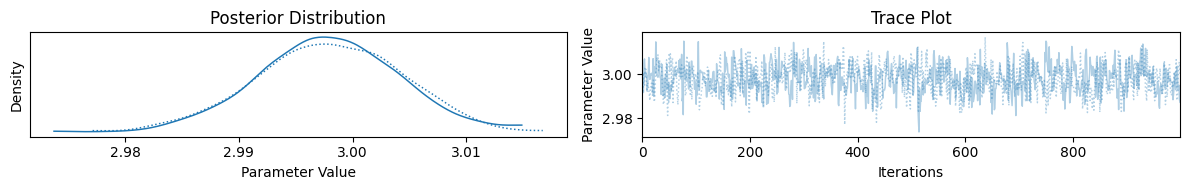

"\n1\nGood Fit: bell-shaped\nx-value at the highest point of the solid line is the best estimate.\nThe fitting results depend on the sample number and the variance.\nIf the smaple number is too small, it's hard to fit.\nIf the variance is too large, then mu can be anywhere.\n\n\n2\nGood Convergence: wiggly.\nBad Convergence: clear trends\n\nWhy wiggly?\nWhen MCMC finds the best/optimal value, it starts to fluctuate around it.\n"

In [ ]:
pm.plot_trace(trace)

plt.subplot(1, 2, 1)
plt.xlabel("Parameter Value")
plt.ylabel("Density")
plt.title("Posterior Distribution")

plt.subplot(1, 2, 2)
plt.xlabel("Iterations")
plt.ylabel("Parameter Value")
plt.title("Trace Plot")

plt.tight_layout()  # Adjust layout for better spacing
plt.show()

#Solid line is Posterior Density Estimation.
#Dotted line is smoothed version of the solid line.

"""
1
Good Fit: bell-shaped
x-value at the highest point of the solid line is the best estimate.
The fitting results depend on the sample number and the variance.
If the smaple number is too small, it's hard to fit.
If the variance is too large, then mu can be anywhere.

2
Good Convergence: wiggly.
Bad Convergence: clear trends

Why wiggly?
When MCMC finds the best/optimal value, it starts to fluctuate around it.
"""

In [ ]:
#pm.model_to_graphviz(model)

In [ ]:
# Get the summary of the trace (mean, std, etc.)
summary = pm.summary(trace)

# Extract the posterior mean and standard deviation for 'mu'
pymc_posterior_mean = summary.loc['mu', 'mean']
pymc_posterior_var = np.square(summary.loc['mu', 'sd'])

print(f"PYMC Posterior Mean: {pymc_posterior_mean}, Variance: {pymc_posterior_var}")

PYMC Posterior Mean: 2.998, Variance: 3.6e-05


### Derivation of the Posterior for $\mu$ and $\sigma^2$

Given the setup:

1. **Prior for \( $\mu$ \)**:  
   $\mu \sim \mathcal{N}(\mu_0, \sigma_0^2)$

2. **Likelihood (data)**:  
   $ x_1, x_2, \dots, x_n \sim \mathcal{N}(\mu, \sigma^2)$

3. **Posterior (using Bayes' theorem)**:  
   The posterior distribution is proportional to the product of the likelihood $p(\text{data} | \mu, \sigma^2)$ and the prior $p(\mu)$:
   $$
   p(\mu, \sigma^2 | \text{data}) \propto p(\text{data} | \mu, \sigma^2) p(\mu)
   $$

According to the question, the variance $\sigma^2$ is known, but we are interested in the posterior of $\mu$ and $\sigma^2$. We can compute the posterior for $\mu$ and $\sigma^2$ using the **conjugate prior** properties.

---

### Derivation of the Posterior for $\mu$

The posterior distribution for $\mu$ given the data is derived by combining the likelihood and prior.

- **Likelihood (Normal with variance $\sigma^2$)**:  
  $$
  p(\text{data} | \mu, \sigma^2) = \prod_{i=1}^n \mathcal{N}(x_i; \mu, \sigma^2)
  $$
  The likelihood for \( n \) observations is given by:
  $$
  p(\text{data} | \mu, \sigma^2) = \left( \frac{1}{\sqrt{2 \pi \sigma^2}} \right)^n \exp\left( -\frac{1}{2 \sigma^2} \sum_{i=1}^n (x_i - \mu)^2 \right)
  $$

- **Prior for $\mu$**:  
  $$
  p(\mu) = \frac{1}{\sqrt{2 \pi \sigma_0^2}} \exp\left( -\frac{1}{2 \sigma_0^2} (\mu - \mu_0)^2 \right)
  $$

Thus, the posterior distribution is proportional to:
$$
p(\mu | \text{data}) \propto p(\text{data} | \mu, \sigma^2) p(\mu)
$$
Combining the likelihood and prior:
$$
p(\mu | \text{data}) \propto \exp\left( -\frac{1}{2 \sigma^2} \sum_{i=1}^n (x_i - \mu)^2 - \frac{1}{2 \sigma_0^2} (\mu - \mu_0)^2 \right)
$$

To simplify, we complete the square on the terms inside the exponential. The result is a Normal distribution for $\mu$:

$$
\mu | \text{data} \sim \mathcal{N}\left( \frac{ \sum_{i=1}^n x_i / \sigma^2 + \mu_0 / \sigma_0^2 }{n / \sigma^2 + 1 / \sigma_0^2}, \frac{1}{n / \sigma^2 + 1 / \sigma_0^2} \right)
$$

Thus, the posterior mean of $\mu$ is:
$$
\mu_{\text{post}} = \frac{\sum_{i=1}^n x_i / \sigma^2 + \mu_0 / \sigma_0^2}{n / \sigma^2 + 1 / \sigma_0^2}
$$

And the posterior variance of $\mu$ is:
$$
\sigma^2_{\mu_{\text{post}}} = \frac{1}{n / \sigma^2 + 1 / \sigma_0^2}
$$


In [ ]:
# Analytical posterior calculation
def analytical_posterior(data, mu0, sigma0_squared, known_variance):
    n = len(data)
    data_mean = np.mean(data)

    posterior_variance = 1 / (n / known_variance + 1 / sigma0_squared)
    posterior_mean = posterior_variance * (data_mean * n / known_variance + mu0 / sigma0_squared)

    return posterior_mean, posterior_variance

posterior_mean, posterior_variance = analytical_posterior(data, mu0, sigma0_squared, mle_variance)
print(f"Analytical Posterior Mean: {posterior_mean}, Variance: {posterior_variance}")


Analytical Posterior Mean: 2.9979005212235186, Variance: 4.01349539414289e-05


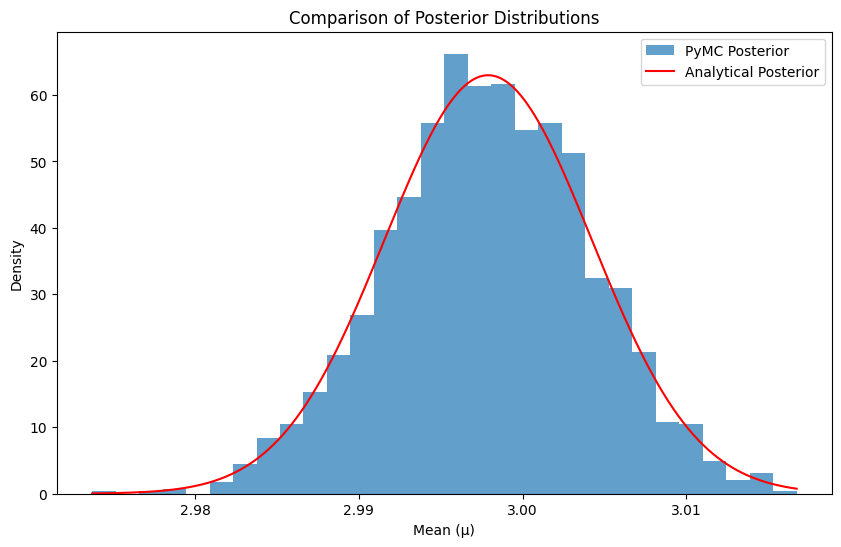

In [ ]:
# Part (c): Compare posterior distributions
# Plot PyMC posterior
pm_posterior_samples = trace.posterior["mu"].values.flatten()
plt.figure(figsize=(10, 6))
plt.hist(pm_posterior_samples, bins=30, density=True, alpha=0.7, label="PyMC Posterior")

# Plot Analytical Posterior
x = np.linspace(min(pm_posterior_samples), max(pm_posterior_samples), 1000)
# norm.pdf() probability density function (PDF) of a normal distribution
plt.plot(x, norm.pdf(x, loc=posterior_mean, scale=np.sqrt(posterior_variance)),
         label="Analytical Posterior", color="red")

plt.title("Comparison of Posterior Distributions")
plt.xlabel("Mean (\u03BC)")
plt.ylabel("Density")
plt.legend()
plt.show()